#### Student information should be written in this cell (Student ID, Student Name).

Name: Madina Alzhanova

ID: 150220939


In [1]:
%load_ext autoreload
%autoreload 2

# HW2: UNSUPERVISED LEARNING WITH AUTOENCODERS

In this homework, you will implement two types of Autoencoders (Basic, and Variational) by using NumPy and PyTorch libraries. For the first question, you will implement and analyze a conventional autoencoder by using only NumPy. For the second question, you will implement a variational autoencoder by using PyTorch. For any of your questions, feel free to e-mail: ergunesr@itu.edu.tr .


## What is an Autoencoder?
An autoencoder is a neural network that is traind to reconstruct its input. It is an unsupervised learning algorithm, the goal is to learn an informative representation of the input data. In this homework, you will implement two autoencoder algorithms for unsupervised learning of an image dataset, MNIST. Before explaining the homework, we will briefly review what autoencoder is. 
    
Now suppose we have only an unlabeled training set 
$ \mathbf{x}=\{ x^{(1)}, x^{(2)}, x^{(3)}, \ldots \} $ , where $x^{(i)} \in \mathbb{R}^n $ . An autoencoder neural network is an unsupervised learning algorithm that applies backpropagation, setting the target values to be equal to the inputs. 
i.e., it uses $y^{(i)} = x^{(i)}$.

 The problem, is to learn the functions   $ A : \mathbb{R}^n \rightarrow \mathbb{R}^p $ (encoder) and  $ B : \mathbb{R}^p \rightarrow \mathbb{R}^n $ (decoder) that satisfy

$$
\arg\min_{A,B} \; \mathbb{E}\!\left[\Delta(\mathbf{x},\, (B \circ A)(\mathbf{x}))\right],
$$

where $ \mathbb{E} $ is the expectation over the distribution of $ \mathbf{x} $ , and  $ \Delta $ is the reconstruction loss function, which measures the distance between the output of the decoder and the input. The encoder $A$ and the decoder $B$ are neural networks.

If the input were completely **random**, say, each $x_i$ comes from an IID Gaussian independent, this compression task would be very difficult. But, if there is a structure in  the data, for example, if some of the input features are correlated, then this algorithm will be able to discover some of those correlations. Further, in the special case where $A$ and $B$ are linear operators, we get linear autoencoders. An autoencoder can be used for compressing the input, or for overcoming the curse of dimensionality. 

Below is an example autoencoder pipeline. Input is an image sample from MNIST dataset. 


![An example autoencoder](autoencoder_image.png)



#### Regularized Autoencoders

The trivial solution in Autoenconders training is solving for identity functions. if the capacity of the encoder and the decoder is large enough to encode each sample to an index, the model would simply overfit. To avoid this, we need regularization. The most common way to regularize an autoencoder is to impose a bottleneck. This means we will directly map the input $\mathbf{x}$ into a lower dimensional space. 

!!! As in many other machine learning models, an important tradeoff in autoencoders is the **bias-variance tradeoff**. On the one hand, we want the architecure of the autoencoder to be able to reconstruct the input well (i.e. reduce the reconstruction error). On the other hand, we want the low representation to generalize to a meaningful one. 



## Q1: Unsupervised learning of MNIST dataset (50 pts)

For the first part of this homework, the task is to implement an unsupervised learning autoencoder pipeline and train it by using MNIST dataset. For this part of the question, you are expected to provide NumPy implementation of your autoencoder. The encoder $A$ and decoder $B$ will each be **one-layer feed-forward neural networks**. 

The loss function of your autoencoder model will be Mean Squared Reconstruction error.

$$ L = \frac{1}{m} \sum_{i=1}^{m} \left\| x^{(i)} - \hat{x}^{(i)} \right\|^{2}
$$ 
where $\hat{x}^{(i)}$ s the reconstructed output of your autoencoder. The dimensionality of the bottleneck, e.g., the output of the encoder $A$, determines the quality of the reconstructed output $\hat{x}^{(i)}$. 


Formally, the **Encoder** is:  
  $$
  A(\mathbf{x}) = \sigma(W_e \mathbf{x} + b_e)
  $$

And the **Decoder** is:
  $$
  B(\mathbf{x}) = \sigma(W_d \mathbf{x} + b_d)
  $$

where $W_e, b_e$ are encoder parameters, $W_d, b_d$ are decoder parameters, $\sigma(\cdot)$ is an activation function (ReLU or sigmoid), $z = A(x)$ is the latent representation. 

Your tasks:
1. **Load and normalize the data**.

2. **Implement the forward pass** of encoder and decoder.  
3. **Compute the reconstruction loss** using Mean Squared Error:  
   $$
   L = \frac{1}{m} \sum_{i=1}^m \left\| x^{(i)} - \hat{x}^{(i)} \right\|^2
   $$
4. **Implement backpropagation manually using NumPy** to compute gradients  
   $$\frac{\partial L}{\partial W_e}, \frac{\partial L}{\partial b_e}, \frac{\partial L}{\partial W_d}, \frac{\partial L}{\partial b_d}$$.
5. **Update parameters with batch gradient descent. After training your model, reconstruct and visualize 10 random training samples and 10 random test samples from MNIST.** 
6. **Implement 3 different autoencoder using latent $z$ dimensions of 16, 32, and 64. Compare and discuss the reconstruction performance for each setting.**


Note that you only need **one encoder layer** and **one decoder layer**.



You will implement your **NumPy-based autoencoder** inside the file **`autoencoder.py`**.  
This file contains a complete class structure `autoencoder.py` with **empty method bodies** and clearly marked **TO DO** sections that you must fill in as part of your implementation.

## MNIST Dataset Overview

As mentioned before, we will work with the **MNIST handwritten digit dataset**. 

Each image is:
- Size: **28 × 28**
- Grayscale (single channel)
- Pixel values in the range **[0, 255]** (you may want to normalize them later)


Now, let's start by downloading the MNIST dataset. 

In [2]:
import urllib.request

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
save_path = "mnist.npz"

print("Downloading MNIST...")
urllib.request.urlretrieve(url, save_path)
print("Download complete: mnist.npz")

Download complete: mnist.npz


Once downloaded, load it by using NumPy:

In [3]:
import numpy as np

with np.load("mnist.npz") as data:
    x_train = data["x_train"]
    y_train = data["y_train"]
    x_test = data["x_test"]
    y_test = data["y_test"]

print("Shapes:", x_train.shape, x_test.shape)

Shapes: (60000, 28, 28) (10000, 28, 28)


We also visualize a few example digits so you can understand the structure of the data you will feed into your NumPy-based autoencoder.

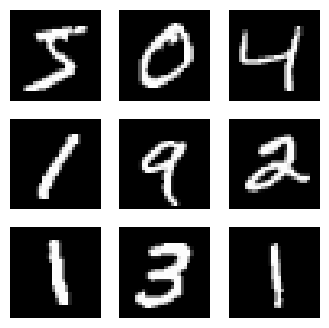

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.show()


Now, you are expected to normalize the data and implement the autoencoder pipeline. You may modify `autoencoder.py` according to your own requirements. To use your implementation, simply import the class from your file with:

In [5]:
# normalize data to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# flatten the images from (28, 28) to (784,)
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

print(f"Training data shape: {x_train_flat.shape}")
print(f"Test data shape: {x_test_flat.shape}")


Training data shape: (60000, 784)
Test data shape: (10000, 784)


In [6]:
from autoencoder import Autoencoder
##### Train your autoencoder for bottleneck sizes 16, 32, and 64 ########

#different bottleneck sizes
bottleneck_sizes = [16, 32, 64]
trained_autoencoders = {}
all_losses = {}

for hidden_dim in bottleneck_sizes:
    print(f"Training Autoencoder with bottleneck size: {hidden_dim}")

    ae = Autoencoder(input_dim = 784, hidden_dim = hidden_dim, learning_rate = 0.1)
   #train and store:
    losses = ae.train(x_train_flat , epochs=50, batch_size=256)
    
    trained_autoencoders[hidden_dim] = ae
    all_losses[hidden_dim] = losses


Training Autoencoder with bottleneck size: 16
Epoch 5/50, Loss: 0.067337
Epoch 10/50, Loss: 0.067298
Epoch 15/50, Loss: 0.067283
Epoch 20/50, Loss: 0.067284
Epoch 25/50, Loss: 0.067282
Epoch 30/50, Loss: 0.067274
Epoch 35/50, Loss: 0.067285
Epoch 40/50, Loss: 0.067280
Epoch 45/50, Loss: 0.067283
Epoch 50/50, Loss: 0.067278
Training Autoencoder with bottleneck size: 32
Epoch 5/50, Loss: 0.067346
Epoch 10/50, Loss: 0.056292
Epoch 15/50, Loss: 0.046665
Epoch 20/50, Loss: 0.042211
Epoch 25/50, Loss: 0.040926
Epoch 30/50, Loss: 0.040514
Epoch 35/50, Loss: 0.040375
Epoch 40/50, Loss: 0.040271
Epoch 45/50, Loss: 0.040165
Epoch 50/50, Loss: 0.040111
Training Autoencoder with bottleneck size: 64
Epoch 5/50, Loss: 0.039696
Epoch 10/50, Loss: 0.026576
Epoch 15/50, Loss: 0.021695
Epoch 20/50, Loss: 0.019451
Epoch 25/50, Loss: 0.018180
Epoch 30/50, Loss: 0.017418
Epoch 35/50, Loss: 0.016957
Epoch 40/50, Loss: 0.016644
Epoch 45/50, Loss: 0.016282
Epoch 50/50, Loss: 0.015961


Visualizing Reconstructions - Bottleneck: 16


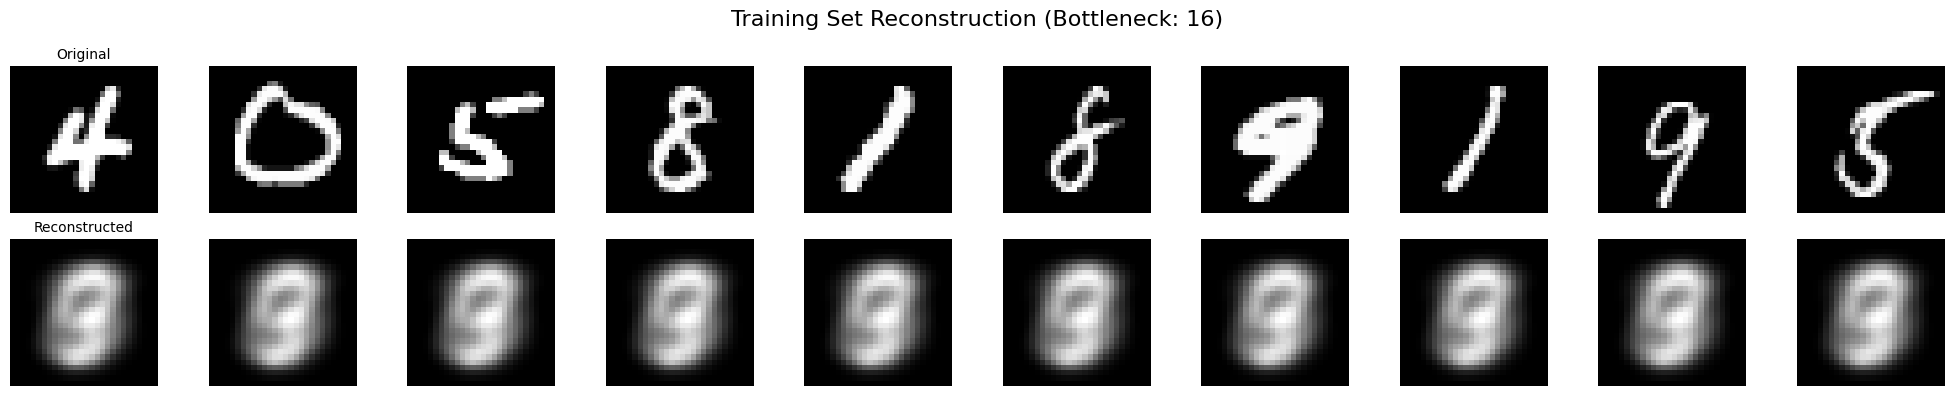

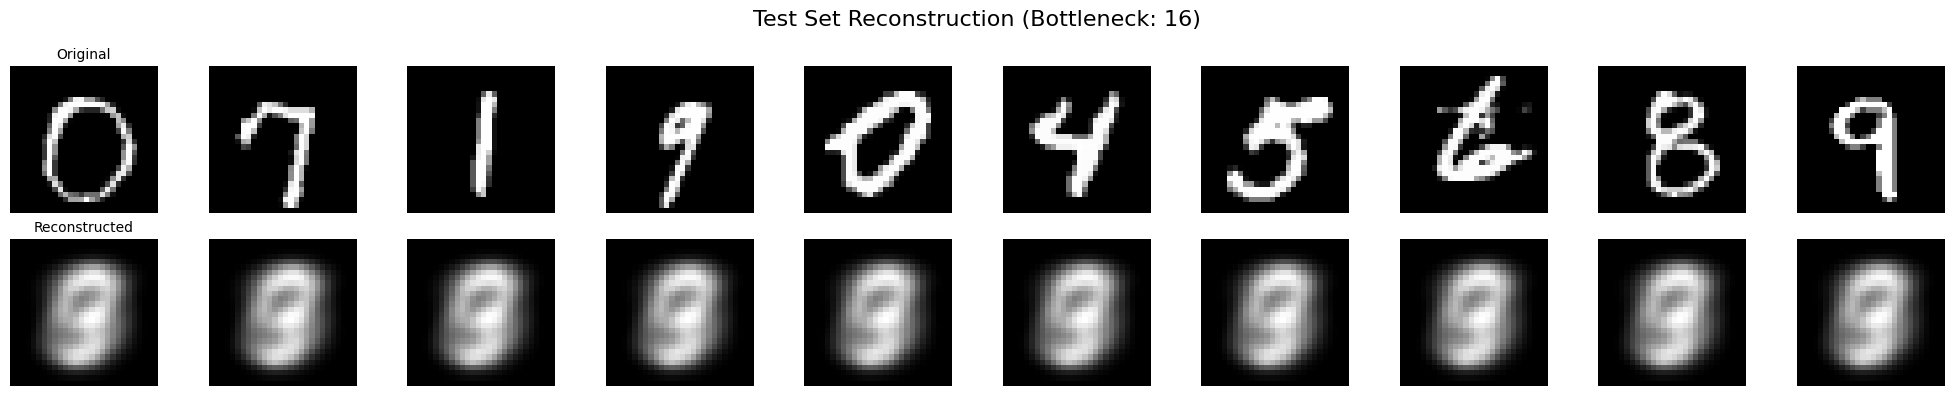

Training MSE: 0.065700
Test MSE: 0.067211
Visualizing Reconstructions - Bottleneck: 32


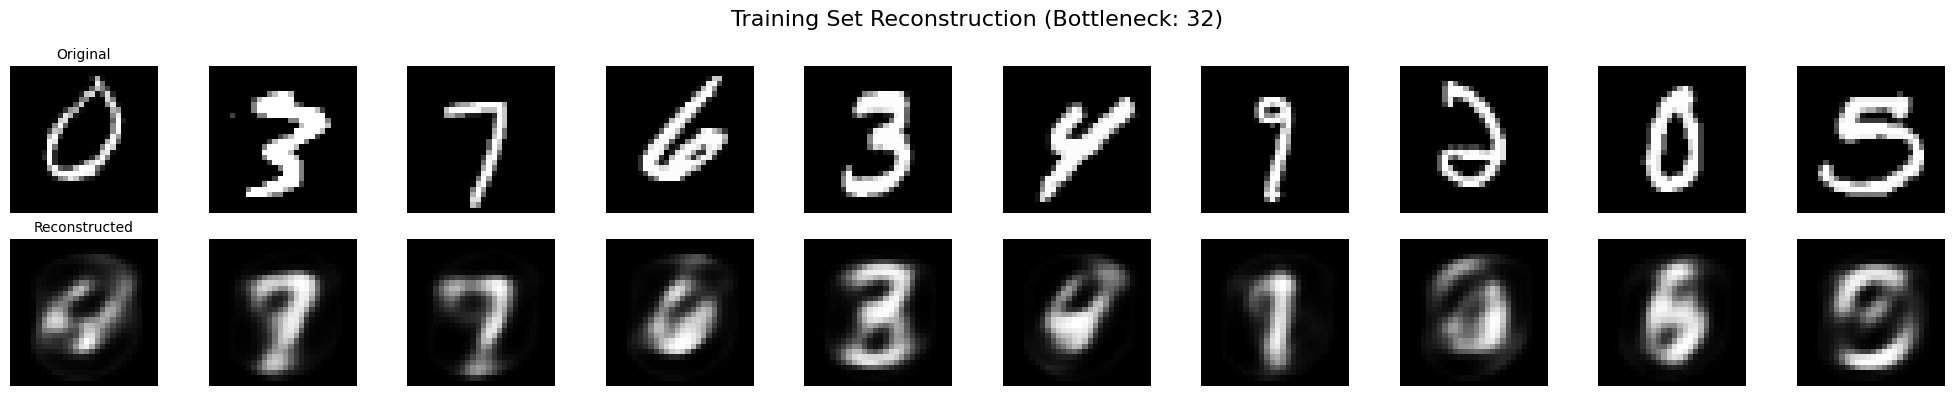

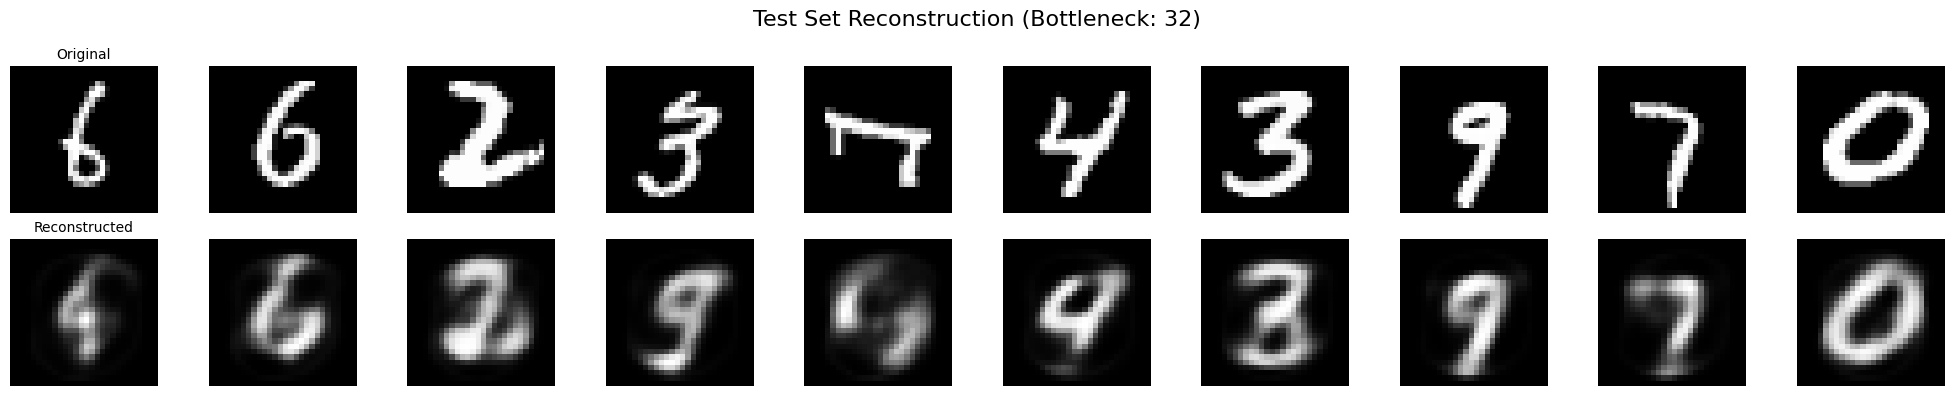

Training MSE: 0.040981
Test MSE: 0.036206
Visualizing Reconstructions - Bottleneck: 64


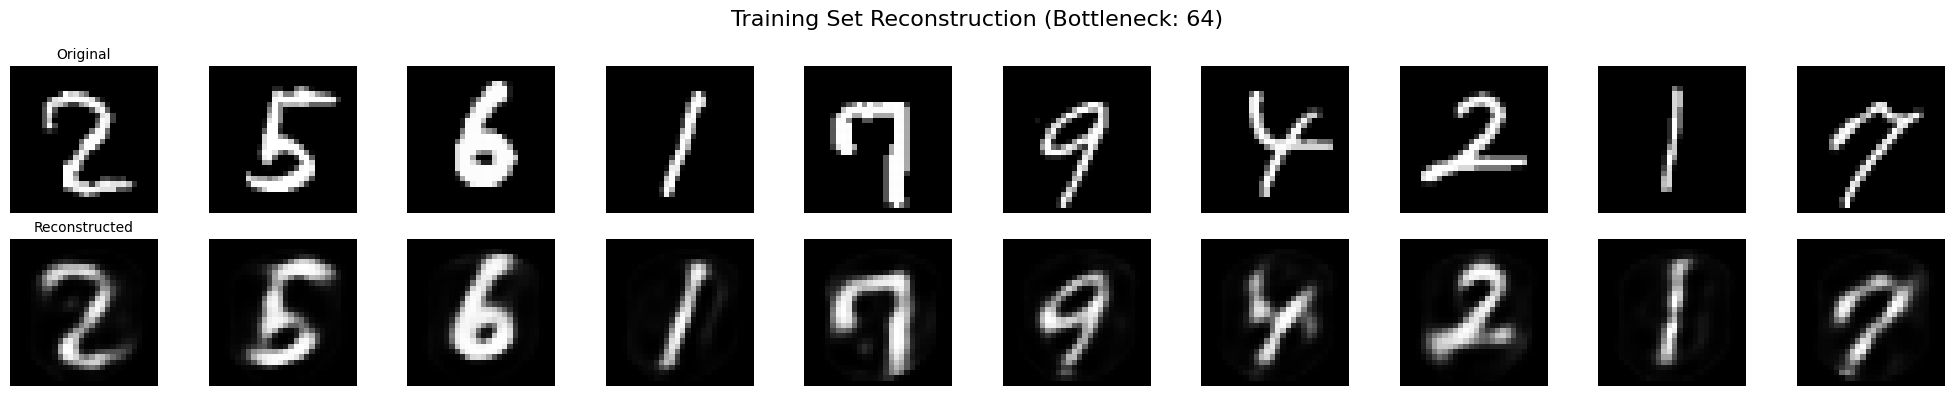

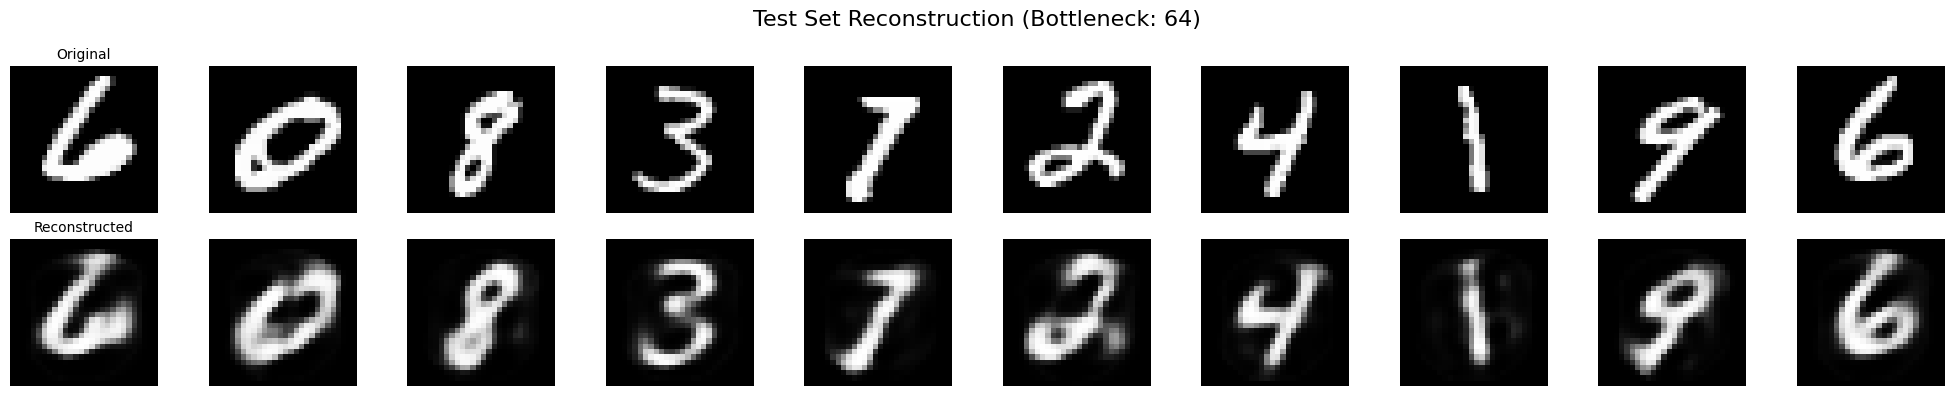

Training MSE: 0.013068
Test MSE: 0.015082


In [7]:
##### TO DO: Visualize reconstructed images for each bottleneck size ########
import matplotlib.pyplot as plt

for hidden_dim in bottleneck_sizes:
    print(f"Visualizing Reconstructions - Bottleneck: {hidden_dim}")
    ae = trained_autoencoders[hidden_dim]

    #choose random samples
    train_indices = np.random.choice(len(x_train_flat), 10, replace=False)
    test_indices = np.random.choice(len(x_test_flat), 10, replace=False)

    #reconstruct train samples
    train_samples = x_train_flat[train_indices].T
    train_z = ae.encoder(train_samples) # z space value
    train_reconstructed = ae.decoder(train_z).T

    #reconstruct test samples
    test_samples = x_test_flat[test_indices].T
    test_z = ae.encoder(test_samples) # z space value
    test_reconstructed = ae.decoder(test_z).T

    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    fig.suptitle(f'Training Set Reconstruction (Bottleneck: {hidden_dim})', fontsize=16)
    
    for i in range(10):
        #original
        axes[0, i].imshow(x_train_flat[train_indices[i]].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=10)
        
        #reconstructed
        axes[1, i].imshow(train_reconstructed[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=10)
    
    plt.tight_layout()
    plt.show()

    # Visualize test samples
    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    fig.suptitle(f'Test Set Reconstruction (Bottleneck: {hidden_dim})', fontsize=16)
    
    for i in range(10):
        # Original
        axes[0, i].imshow(x_test_flat[test_indices[i]].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=10)
        
        # Reconstructed
        axes[1, i].imshow(test_reconstructed[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=10)
    
    plt.tight_layout()
    plt.show()

    # Compute and print reconstruction errors
    train_mse = np.mean((train_samples.T - train_reconstructed) ** 2)
    test_mse = np.mean((test_samples.T - test_reconstructed) ** 2)
    print(f"Training MSE: {train_mse:.6f}")
    print(f"Test MSE: {test_mse:.6f}")

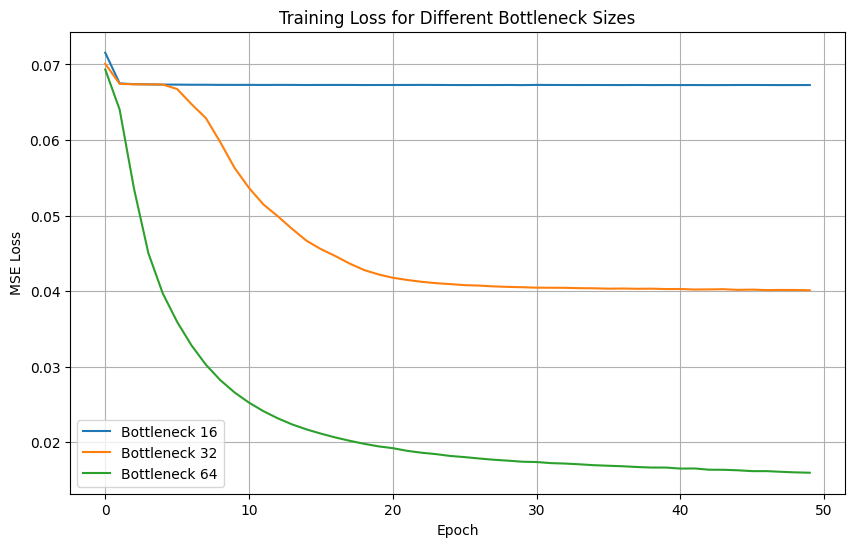

In [8]:
##### TO DO: Report your training metrics and plots such as training loss plot

plt.figure(figsize=(10, 6))
for hidden_dim in bottleneck_sizes:
    plt.plot(all_losses[hidden_dim], label=f'Bottleneck {hidden_dim}')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss for Different Bottleneck Sizes')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from autoencoder import Autoencoder


##### TO DO: Implement the encoder forward pass ############
##### TO DO: Implement the decoder forward pass ############
##### TO DO: Implement backpropagation for encoder and decoder ########
##### TO DO: Implement the full autoencoder forward function (call encoder + decoder) #######
##### TO DO: Compute the reconstruction loss (MSE) #########
##### TO DO: Update parameters using gradient descent ########
##### TO DO: Train your autoencoder for bottleneck sizes 16, 32, and 64 ########
##### TO DO: Visualize reconstructed images for each bottleneck size ########
##### TO DO: Report your training metrics and plots such as training loss plot
##### TO DO: Compare and discuss reconstruction performance on training and test examples ########

##### TO DO: Compare and discuss reconstruction performance on training and test examples ########
The MSE drops significantly as bottleneck size increases. This is because it is easier to reconstruct the image when size of vector in z space is larger. We can see that increasing bottleneck size provides sharper and correct reconstructed images both for training and test samples.  

## Structure in Embeddings 
In a trained autoencoder, the embedding space should reflect the structure of the data, mapping similar images to nearby points. Select two images from the MNIST training set, compute their embeddings using the encoder, and generate interpolated embeddings between them. Decode these interpolated embeddings and visualize the reconstructions to observe the smooth transitions. Repeat the procedure for two images of different digits. Implement this process in PyTorch and analyze how the embedding space captures the semantic similarity between digits.

In [10]:
ae_interpolation = trained_autoencoders[64]

def interpolate_embeddings(ae, img1, img2, steps=10):
    # encode both images to z space, normalize
    z1 = ae.encoder(img1.reshape(-1, 1))
    z2 = ae.encoder(img2.reshape(-1, 1))

    #steps 0 0.1 0.2 ... 0.9 1.0
    alphas = np.linspace(0, 1, steps)
    interpolated_images = []
    for alpha in alphas:
        #linear Interpolation
        z_interp = (1 - alpha) * z1 + alpha * z2

        #decode interpolated image
        x_interp = ae.decoder(z_interp)
        interpolated_images.append(x_interp.reshape(28, 28))

    return interpolated_images

Case 1: Same Digit (3)


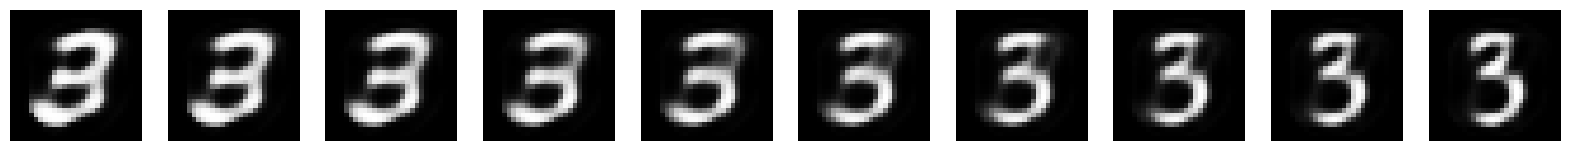

In [11]:
print("Case 1: Same Digit (3)")

# 1. Find indices of all '3's in the dataset
digit_to_find = 3
# np.where returns a list of indices where the condition is true
same_digit_indices = np.where(y_train == digit_to_find)[0]

# 2. Pick two different '3's (e.g., the 1st one and the 11th one)
idx1 = same_digit_indices[0]
idx2 = same_digit_indices[10]

img1 = x_train_flat[idx1]
img2 = x_train_flat[idx2]

# 3. Run the function
interpolated_same = interpolate_embeddings(ae_interpolation, img1, img2)

# 4. Visualize
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i, img in enumerate(interpolated_same):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
plt.show()



Case 2: Different Digits (1 -> 0)


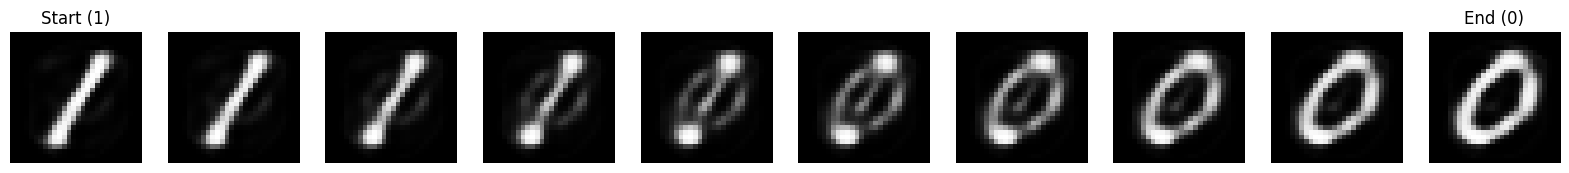

In [12]:
print("Case 2: Different Digits (1 -> 0)")

# 1. Find a 1 and 0
idx1 = np.where(y_train == 1)[0][0] # First '1' it finds
idx2 = np.where(y_train == 0)[0][0] # First '0' it finds

img1_diff = x_train_flat[idx1]
img2_diff = x_train_flat[idx2]

# 2. Run interpolation
interpolated_diff = interpolate_embeddings(ae_interpolation, img1_diff, img2_diff)

# 3. Visualize
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i, img in enumerate(interpolated_diff):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    if i == 0: axes[i].set_title("Start (1)")
    if i == 9: axes[i].set_title("End (0)")
plt.show()

In [13]:
# 1. Get the Z vectors
z1_same = ae_interpolation.encoder(img1.reshape(-1, 1))
z2_same = ae_interpolation.encoder(img2.reshape(-1, 1))

z1_diff = ae_interpolation.encoder(img1_diff.reshape(-1, 1))
z2_diff = ae_interpolation.encoder(img2_diff.reshape(-1, 1))

# 2. Calculate Distance: sqrt(sum((a-b)^2))
dist_same = np.linalg.norm(z1_same - z2_same)
dist_diff = np.linalg.norm(z1_diff - z2_diff)

print(f"Distance between two 3s: {dist_same:.4f}")
print(f"Distance between 1 and 0: {dist_diff:.4f}")

Distance between two 3s: 2.6057
Distance between 1 and 0: 2.9921


## Q2 - Unsupervised learning of MNIST dataset by using Variational Autoencoders (50 pts)

A **Variational Autoencoder (VAE)** is a **probabilistic generative model** that learns a **latent distribution** of the data instead of just deterministic embeddings like a standard autoencoder.  

VAEs enable us to sample new data points. Generative models capture the underlying dynamics of the data distributions, and can generate new samples according to them.

Just like a standard Autoencoder, a VAE consists of two main components: An Encoder and a Decoder. The Encoder maps an input $\mathbf{x}$ to a **latent distribution** $q_\phi(z|x)$, parameterized by a mean $\mu$ and log-variance $\log \sigma^2$.  

The Decoder samples the latent representation $z \sim q_\phi(z|x)$ and reconstructs the input via $p_\theta(x|z)$. In VAE, instead of learning the latent representations directly, we are trying to learn the distributions that generate the latent representations.

**For MNIST, you will use the following parameters as before:**
- Input: 28×28 images (flattened to 784-dim vectors)
- Latent dimensions: 16, 32, or 64
- Encoder: 784 → hidden_dim → 2 × latent_dim (outputs $\mu$ and $\log \sigma^2$ )
- Decoder: latent_dim → hidden_dim → 784 (reconstructs the image)

In this question, you will need to use ReLU as encoder's activation function, and Sigmoid for Decoder's activation functions.


### The Loss Function

The VAE is trained by maximizing the **Evidence Lower Bound (ELBO)**:

$$ 
\mathcal{L}(\theta, \phi; x) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_{KL}\big(q_\phi(z|x) \parallel p(z)\big)
$$

Where the first term is a reconstruction loss and the second term is KL-divergence term. The reconstruction loss measures how well the decoder reconstructs the input. For MNIST, **Binary Cross-Entropy (BCE)** is commonly used.

### **KL Divergence**  

$$
D_{KL}\big(q_\phi(z|x) \parallel p(z)\big) = -\frac{1}{2} \sum_{i=1}^{d} \big(1 + \log \sigma_i^2 - \mu_i^2 - \sigma_i^2\big)
$$ 

Regularizes the latent distribution $q_\phi(z|x)$ to be close to the prior $ p(z) = \mathcal{N}(0, I)$.



### Reparameterization Trick

Directly sampling $z \sim q_\phi(z|x)$ is **non-differentiable**, which prevents backpropagation. To fix this, we use reparameterization trick in computation of the forward pass. Reparameterization is an essential trick for training a variational autoencoder. The latent representation is computed by using the following expression, instead of being directly sampled from $q_\phi(z|x)$. 

$$ 
z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)
$$

This way, the gradients to flow through $\mu$ and $\sigma$ during training. For each neuron, there exists be a $\mu$ and a $\sigma$ parameter.


### Using PyTorch in This Homework


In this question, we will use **PyTorch**, a popular open-source library for **deep learning** and **tensor computations**. PyTorch provides tools for building neural networks, automatic differentiation, and efficient computation on **CPU** or **GPU**. For this homework, a **CPU-only setup is sufficient**.

You can install PyTorch by running:

```python
!pip install torch torchvision torchaudio

#### Some useful PyTorch components you will need: (For more you can check PyTorch documents.)
- **Tensors** (`torch.Tensor`) for storing and manipulating data. Think of them as multidimensional arrays, similar to NumPy arrays.
- **`torch.nn.Module`** to define neural network models.
- **`torch.nn.functional`** for activation functions, loss functions, and other operations.
- **`torch.optim`** for optimization routines like SGD or Adam.
- **Automatic differentiation** via `tensor.backward()` to compute gradients.

#### What You Will Implement Manually?
While PyTorch handles gradients and basic tensor operations, you will need to implement **the autoencoder and variational autoencoder architectures**, the **forward pass**, the **reparameterization trick** for the VAE, and **the training loop** manually. This will help you understand the underlying mechanics of these models.

Here, you are provided with a template file `VAE.py`. Your task is to **fully implement all the methods in this file**. This includes:  

- **Encoder**: maps input images to the latent mean and log-variance vectors.  
- **Reparameterization**: samples latent vectors from the encoder’s distribution.  
- **Decoder**: reconstructs images from latent vectors.  
- **Forward pass**: integrates encoder, reparameterization, and decoder.  
- **Loss computation**: combines reconstruction loss and KL divergence.  
- **Training loop**: updates model parameters using an optimizer.  

Then, you can import your module, and call the functions in the following cell to implement this question.

In [14]:
from VAE import VAE

##### TO DO: Implement the encoder network to output mean and log-variance #####
##### TO DO: Implement the reparameterization trick to sample latent vectors #####
##### TO DO: Implement the decoder network to reconstruct images from latent vectors #####
##### TO DO: Implement the full forward pass (encoder -> reparameterization -> decoder) #####
##### TO DO: Compute the reconstruction loss (e.g., MSE or BCE) #####
##### TO DO: Compute the KL divergence loss for the latent distribution #####
##### TO DO: Combine reconstruction + KL loss to form the total loss #####
##### TO DO: Update model parameters using an optimizer (e.g., Adam) #####
##### TO DO: Train your VAE for latent sizes 16, 32, and 64 #####
##### TO DO: Visualize reconstructed images and optionally latent space samples #####
##### TO DO: Report your training metrics and plots such as training loss plot. #####
##### TO DO: Compare and discuss reconstruction quality and latent space structure #####

In [15]:
##### TO DO: Train your VAE for latent sizes 16, 32, and 64 #####

import torch
import numpy as np
import matplotlib.pyplot as plt
from VAE import VAE
# convertt to tensor
if 'x_train_tensor' not in locals():
    x_train_tensor = torch.from_numpy(x_train_flat).float()
    x_test_tensor = torch.from_numpy(x_test_flat).float()

latent_sizes = [16, 32, 64]  # bottleneck sizes
trained_vaes = {}
all_vae_losses = {}
device = 'cpu'

# 3. Training Loop
for latent_dim in latent_sizes:
    #init vae:
    vae = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim)

    #train
    losses = vae.train_vae(x_train_tensor, epochs=50, batch_size=128, learning_rate=1e-3, device=device)

    # Store results
    trained_vaes[latent_dim] = vae
    all_vae_losses[latent_dim] = losses


Epoch 5/50, Loss: 14126.4538
Epoch 10/50, Loss: 13646.1632
Epoch 15/50, Loss: 13455.9389
Epoch 20/50, Loss: 13331.8263
Epoch 25/50, Loss: 13246.9803
Epoch 30/50, Loss: 13180.6137
Epoch 35/50, Loss: 13127.8402
Epoch 40/50, Loss: 13088.6761
Epoch 45/50, Loss: 13052.7435
Epoch 50/50, Loss: 13017.4711
Epoch 5/50, Loss: 14094.8870
Epoch 10/50, Loss: 13569.5531
Epoch 15/50, Loss: 13388.0729
Epoch 20/50, Loss: 13277.6237
Epoch 25/50, Loss: 13210.4376
Epoch 30/50, Loss: 13153.6065
Epoch 35/50, Loss: 13113.2909
Epoch 40/50, Loss: 13071.6356
Epoch 45/50, Loss: 13040.8863
Epoch 50/50, Loss: 13018.8716
Epoch 5/50, Loss: 14187.7137
Epoch 10/50, Loss: 13594.1054
Epoch 15/50, Loss: 13393.3066
Epoch 20/50, Loss: 13295.3541
Epoch 25/50, Loss: 13221.5323
Epoch 30/50, Loss: 13166.5739
Epoch 35/50, Loss: 13117.8277
Epoch 40/50, Loss: 13088.9380
Epoch 45/50, Loss: 13054.4731
Epoch 50/50, Loss: 13025.2554


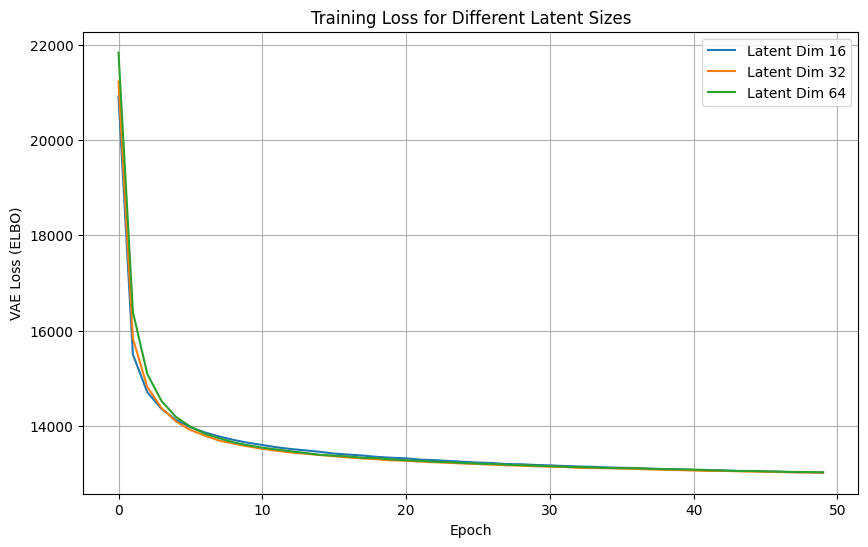

In [16]:
##### TO DO: Report your training metrics and plots such as training loss plot. #####
plt.figure(figsize=(10, 6))
for latent_dim in latent_sizes:
    plt.plot(all_vae_losses[latent_dim], label=f'Latent Dim {latent_dim}')
plt.xlabel('Epoch')
plt.ylabel('VAE Loss (ELBO)')
plt.title('Training Loss for Different Latent Sizes')
plt.legend()
plt.grid(True)
plt.show()

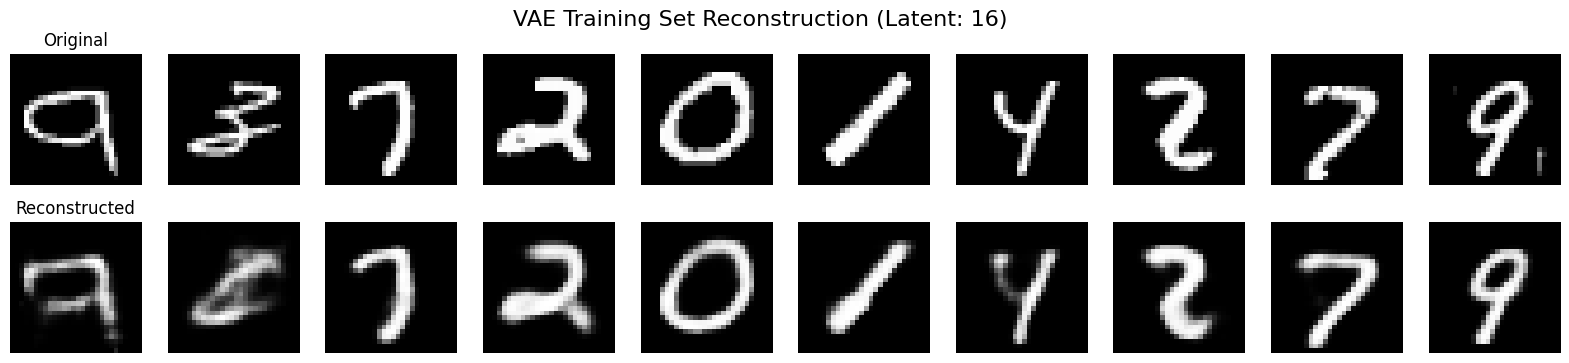

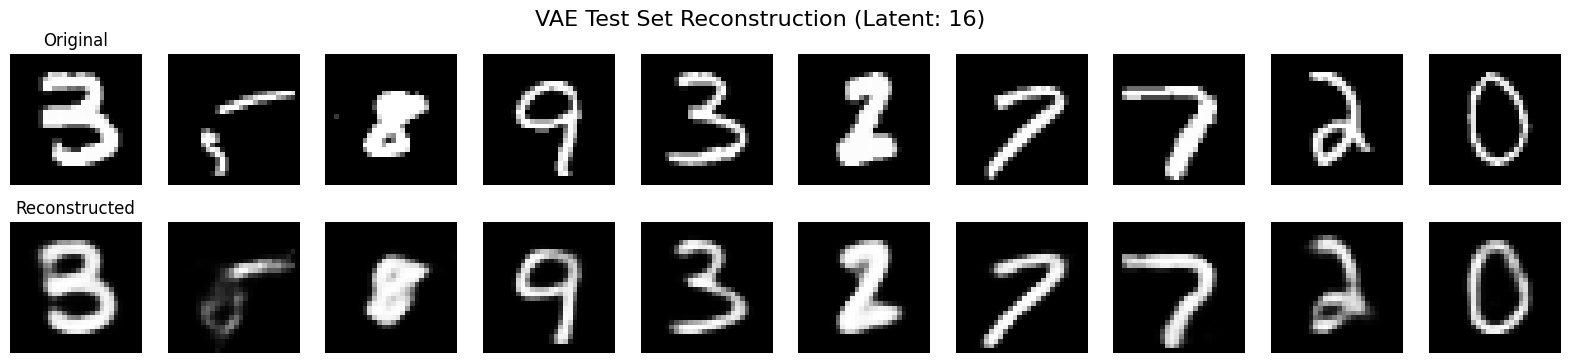

Training MSE: 0.014565
Test MSE: 0.014237


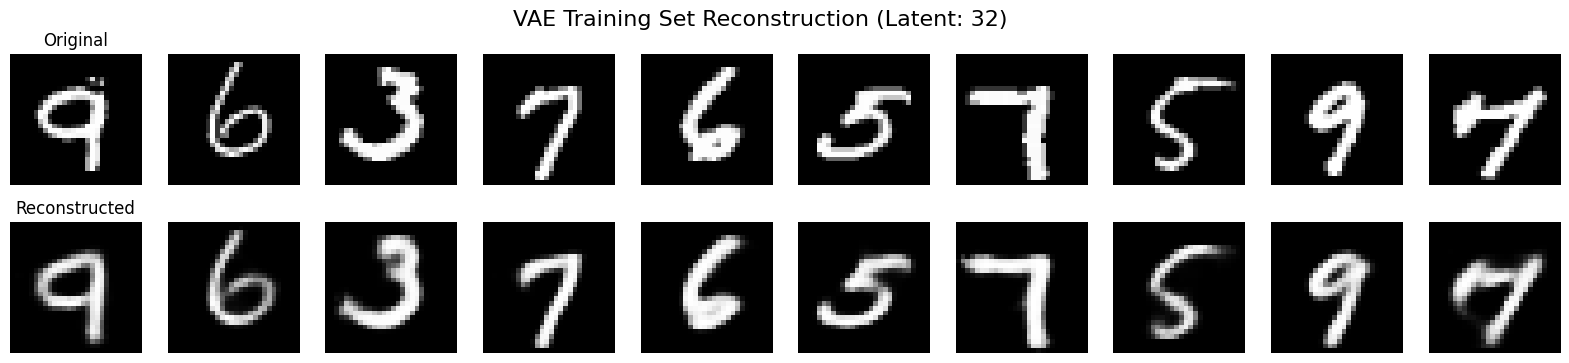

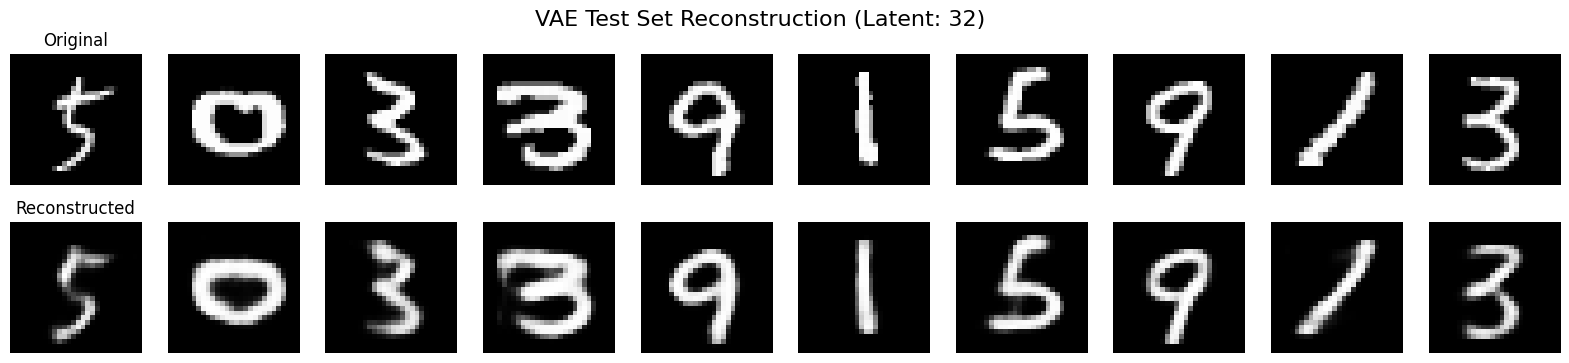

Training MSE: 0.009951
Test MSE: 0.011022


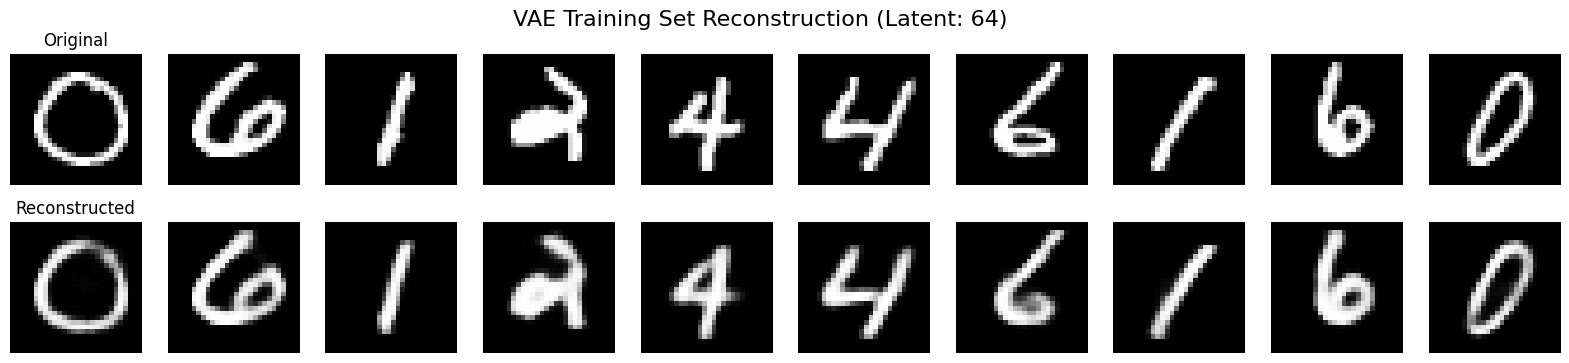

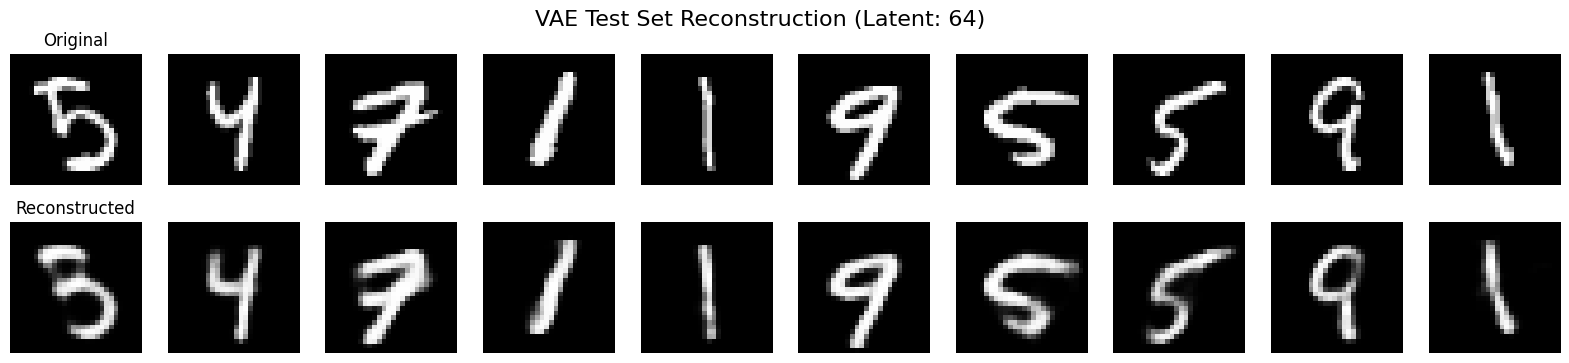

Training MSE: 0.009836
Test MSE: 0.009552


In [17]:
##### TO DO: Visualize reconstructed images and optionally latent space samples #####
for latent_dim in latent_sizes:
    vae = trained_vaes[latent_dim]
    vae.eval()

    # Select random samples (Indices)
    train_indices = np.random.choice(len(x_train_tensor), 10, replace=False)
    test_indices = np.random.choice(len(x_test_tensor), 10, replace=False)
    
    #Helper to get reconstructions
    def get_recon(model, data_tensor, indices):
        samples = data_tensor[indices].to(device)
        with torch.no_grad():
            reconstructed, _, _ = model(samples)
        return samples.cpu().numpy(), reconstructed.cpu().numpy()

    train_org, train_recon = get_recon(vae, x_train_tensor, train_indices)
    test_org, test_recon = get_recon(vae, x_test_tensor, test_indices)

    #training set
    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    fig.suptitle(f'VAE Training Set Reconstruction (Latent: {latent_dim})', fontsize=16)
    
    for i in range(10):
        # Original
        axes[0, i].imshow(train_org[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title('Original')
        
        # Reconstructed
        axes[1, i].imshow(train_recon[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title('Reconstructed')
    plt.show()

    # test set
    fig, axes = plt.subplots(2, 10, figsize=(20, 4))
    fig.suptitle(f'VAE Test Set Reconstruction (Latent: {latent_dim})', fontsize=16)
    
    for i in range(10):
        # Original
        axes[0, i].imshow(test_org[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title('Original')
        
        # Reconstructed
        axes[1, i].imshow(test_recon[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title('Reconstructed')
    plt.show()

#mse for comparing 
    train_mse = np.mean((train_org - train_recon) ** 2)
    test_mse = np.mean((test_org - test_recon) ** 2)
    print(f"Training MSE: {train_mse:.6f}")
    print(f"Test MSE: {test_mse:.6f}")


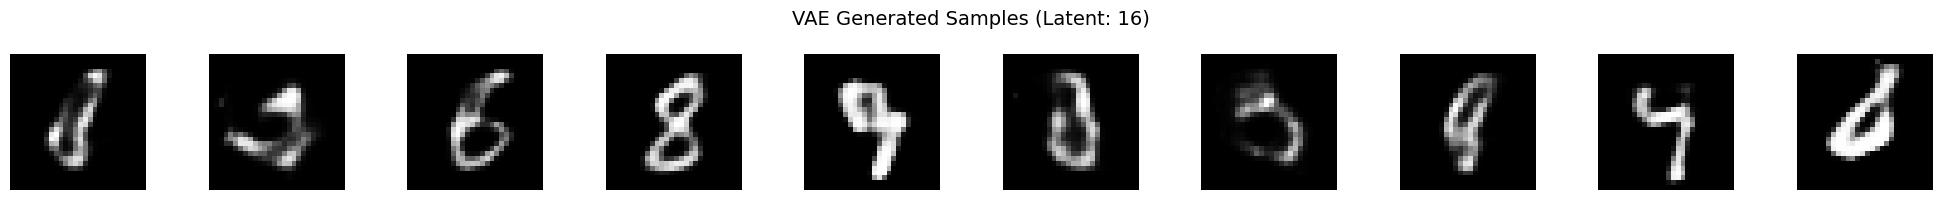

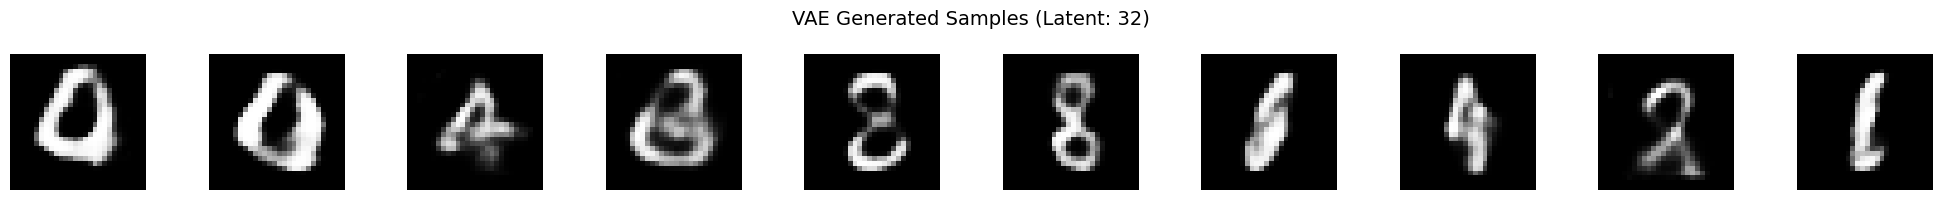

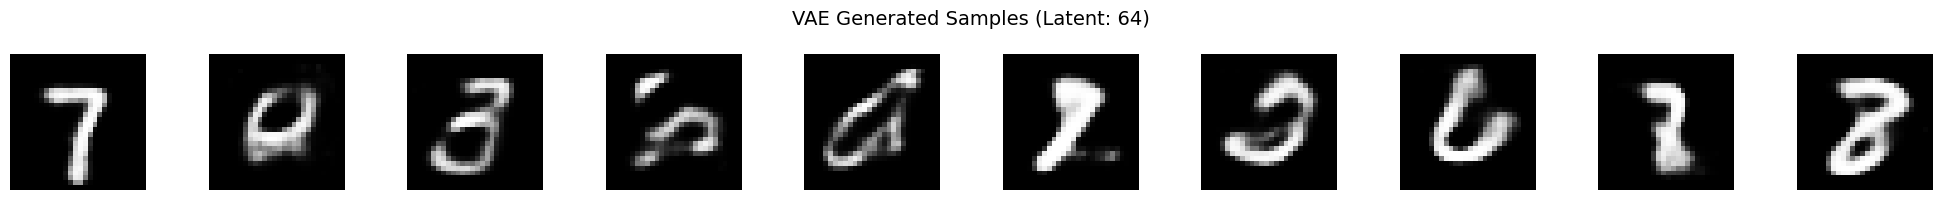

In [ ]:
# generate new digits
for latent_dim in latent_sizes:
    vae = trained_vaes[latent_dim]
    vae.eval()
    
    with torch.no_grad():
        # Sample random latent vectors
        z_samples = torch.randn(10, latent_dim)
        
        #decode to generate images
        generated = vae.decode(z_samples)
    
    # Visualize generated samples
    fig, axes = plt.subplots(1, 10, figsize=(20, 2))
    fig.suptitle(f'VAE Generated Samples (Latent: {latent_dim})', fontsize=14)
    
    for i in range(10):
        axes[i].imshow(generated[i].reshape(28, 28).numpy(), cmap='gray')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

## Comparison of Standard Autoencoders and Variational Autoencoders

Once you have implemented both the standard autoencoder and the variational autoencoder, you can analyze and compare them along:

**Reconstruction Quality**  
   - Compare reconstructed images from both models on 10 sample training image and 10 sample test image.  
   - Note how accurately each model preserves details of the input images.

Important: Please read the questions and #TODOs carefully to implement all the steps to complete the assignment. You may add or subtract methods to the python scripts according to your needs. Feel free to e-mail ergunesr@itu.edu.tr for your questions.  

In [31]:
latent_dim = 32  # We compare the 32-dim versions
device = 'cpu'

# get the models
ae_model = trained_autoencoders[latent_dim] 
vae_model = trained_vaes[latent_dim]        
vae_model.eval()                            

#get random samples
np.random.seed(42) 
train_idx = np.random.choice(len(x_train_flat), 10, replace=False)
test_idx = np.random.choice(len(x_test_flat), 10, replace=False)

def get_comparisons(indices, data_flat):
    # originals
    originals = data_flat[indices]

    #AE
    z_ae = ae_model.encoder(originals.T)
    ae_recon = ae_model.decoder(z_ae).T

    #VAE
    data_tensor = torch.tensor(originals).float().to(device)
    with torch.no_grad():
        vae_recon_t, _, _ = vae_model(data_tensor)
    vae_recon = vae_recon_t.cpu().numpy()
    
    return originals, ae_recon, vae_recon

# Get data
tr_orig, tr_ae, tr_vae = get_comparisons(train_idx, x_train_flat)
te_orig, te_ae, te_vae = get_comparisons(test_idx, x_test_flat)


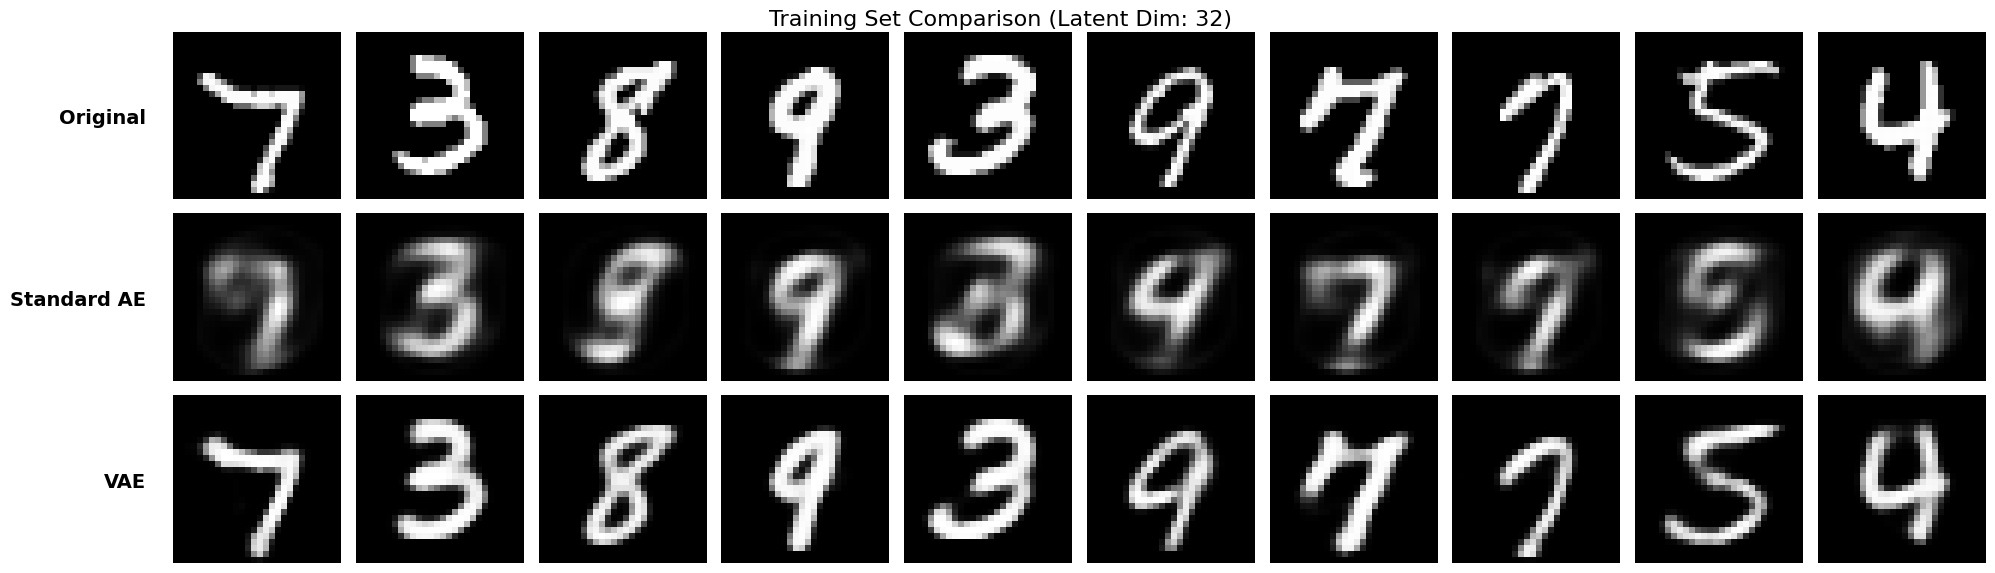

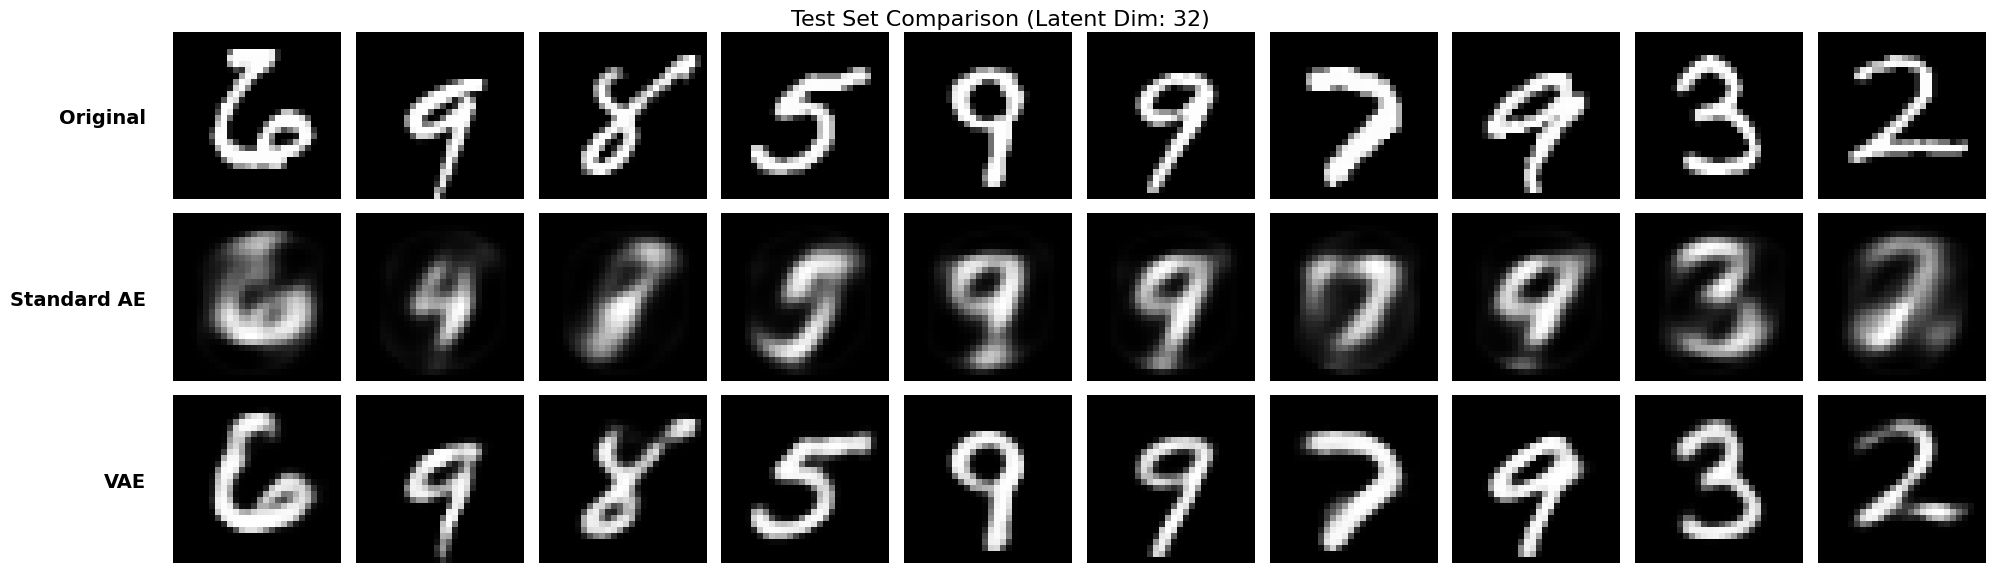

Standard AE MSE: 0.038594
VAE MSE:         0.012083


In [32]:
def plot_comparison(orig, ae, vae, title):
    fig, axes = plt.subplots(3, 10, figsize=(20, 6))
    fig.suptitle(title, fontsize=16, y=0.95)
    
    rows = ["Original", "Standard AE", "VAE"]
    data = [orig, ae, vae]
    
    for row_idx, img_data in enumerate(data):
        for col_idx in range(10):
            ax = axes[row_idx, col_idx]
            ax.imshow(img_data[col_idx].reshape(28, 28), cmap='gray')
            ax.axis('off')
            
            # Add Row Labels
            if col_idx == 0:
                ax.text(-5, 14, rows[row_idx], fontsize=14, va='center', ha='right', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Plot Training Set
plot_comparison(tr_orig, tr_ae, tr_vae, f"Training Set Comparison (Latent Dim: {latent_dim})")

# Plot Test Set
plot_comparison(te_orig, te_ae, te_vae, f"Test Set Comparison (Latent Dim: {latent_dim})")


ae_mse_test = np.mean((te_orig - te_ae) ** 2)
vae_mse_test = np.mean((te_orig - te_vae) ** 2)

print(f"Standard AE MSE: {ae_mse_test:.6f}")
print(f"VAE MSE:         {vae_mse_test:.6f}")

I expected VAE to have blurrier results that standard AE due to normal distribution. However from the reconstruction for 32 bits, it is clear that VAE is much sharper and VAE's MSE is about 3 times less. I believe this is due to different loss functions used in two methods: MSE vs BCE. BCE panlizes grey pixels, thats why reconstructed images are sharper.

Also VAE is generative model due to probabilistic distribution. The VAE explicitly learns the distribution of z. It can generate a digit by taking z-value and decoding it. VAE Latent space is dense, so getting random vector from there will give a value close to some of the digits. While in AE latent space, getting random vector may give just noise because it contains empty areas. 

VAE is pretty accurate in reconstructing the small details in digits.